# Pseudo-Dirac neutrinos

Each Dirac neutrino may in fact be two Majorana states separated by a tiny mass-squared
splitting $\delta m^2$. The consequence is a separation of scales, and the separation is the
whole physical content: over an astrophysical baseline the standard splittings have long since
averaged away, while each pseudo-Dirac pair is still only part-way through its first cycle.

That is precisely the regime the **coherent-block** averaging form is for. Summing
probabilities eigenstate by eigenstate -- the form that is right once everything has decohered
-- undercounts here by the number of states sharing a block, which for a fully paired spectrum
is a factor of two.

This notebook builds the Hamiltonian, checks it reduces exactly to the Dirac case when nothing
is paired, and then works through the two regimes: the oscillatory one, where only the
un-averaged probability is valid, and the averaged one, where the block form is. It closes on
two negative results that are as useful as the positive ones -- the instantaneous probability
is not an observable at astrophysical distances, and the effect is invisible on Earth.

In [1]:
# The figures are set through LaTeX where one is available; where it is not,
# matplotlib's own mathtext renders the labels instead.  Same numbers either way.
import shutil

import matplotlib.pyplot as plt

plt.rcParams['text.usetex'] = shutil.which('latex') is not None

## 1. The construction

`pseudo_dirac_mixing_matrix` replaces each paired mass eigenstate $j$ by the two combinations
$(|\nu_j\rangle \pm |s_j\rangle)/\sqrt{2}$, and `pseudo_dirac_mass_squared` gives them masses
$m_j^2$ and $m_j^2 + \delta m^2_j$. Pairing is chosen **per mass state**: a three-flavor
spectrum with partners on two of its three states is a five-dimensional problem.

In [2]:
import warnings

import numpy as np
import matplotlib.pyplot as plt

import magnus.avgprob as avgprob
import magnus.globaldefs as gd
import magnus.hamiltonians as hamiltonians
import magnus.oscprob as oscprob

MPC_IN_KM = 3.0856775814913673e19        # 1 Mpc, in km

OSC = gd.load_nufit_params('NuFIT 6.1', 'NO')
U = hamiltonians.pmns_mixing_matrix(OSC['s12'], OSC['s23'], OSC['s13'], OSC['dCP'])
M2 = [0.0, OSC['D21'], OSC['D31']]

for pairs in ({}, {1: 1.0e-18}, {0: 1.0e-18, 2: 4.0e-18},
              {0: 1.0e-18, 1: 1.0e-18, 2: 1.0e-18}):
    W = hamiltonians.pseudo_dirac_mixing_matrix(U, pairs)
    unitary = np.allclose(W @ np.conj(W.T), np.eye(len(W)), atol=1.0e-14)
    print('pairs on %-9s -> %d states, unitary: %s'
          % (str(sorted(pairs)) if pairs else 'none', len(W), unitary))

pairs on none      -> 3 states, unitary: True
pairs on [1]       -> 4 states, unitary: True
pairs on [0, 2]    -> 5 states, unitary: True
pairs on [0, 1, 2] -> 6 states, unitary: True


### Nothing paired is the Dirac case, exactly

Not approximately. With an empty pairing the same matrices are multiplied in the same order as
in `hamiltonian_3nu_vacuum_energy_independent`, so the two agree to round-off. A builder that
only *nearly* reduced would be hiding a convention difference.

In [3]:
H_pd = hamiltonians.hamiltonian_pseudo_dirac_vacuum_energy_independent(U, M2, {})
H_3nu = hamiltonians.hamiltonian_3nu_vacuum_energy_independent(
    OSC['s12'], OSC['s23'], OSC['s13'], OSC['dCP'], OSC['D21'], OSC['D31'])

print('max |H_pseudo-Dirac - H_3nu| = %.2e' % float(np.max(np.abs(H_pd - H_3nu))))

max |H_pseudo-Dirac - H_3nu| = 2.17e-19


## 2. The separation of scales

The ratio of the pair phase to the standard one is $\delta m^2/\Delta m^2_{31}$, and nothing
in the setup can change it. That single fact organizes everything below: at a splitting small
enough to be pseudo-Dirac, **you cannot have a resolvable standard oscillation and a
developing pair phase at the same time.**

In [4]:
def phase(dm2, L_km, energy):
    """The relative phase dm^2 L / (4E), in radians."""
    return dm2*(L_km*gd.UNIT_KM)/(4.0*energy)

print('%-38s %12s %12s' % ('configuration', 'pair phase', 'Dm31 phase'))
print('-'*64)
for label, dm2, L_km, energy in (
        ('100 Mpc, 100 TeV, dm2 = 2.6e-17', 2.6e-17, 100.0*MPC_IN_KM, 100.0*gd.UNIT_TEV),
        ('10 Mpc,  100 TeV, dm2 = 2.6e-16', 2.6e-16, 10.0*MPC_IN_KM, 100.0*gd.UNIT_TEV),
        ('1300 km, 1 GeV,   dm2 = 2.6e-17', 2.6e-17, 1300.0, 1.0*gd.UNIT_GEV)):
    print('%-38s %12.3g %12.3g'
          % (label, phase(dm2, L_km, energy), phase(OSC['D31'], L_km, energy)))

configuration                            pair phase   Dm31 phase
----------------------------------------------------------------
100 Mpc, 100 TeV, dm2 = 2.6e-17                1.02     9.82e+13
10 Mpc,  100 TeV, dm2 = 2.6e-16                1.02     9.82e+12
1300 km, 1 GeV,   dm2 = 2.6e-17            4.28e-14         4.14


## 3. The oscillatory regime

Here the pair phase is $O(1)$ and the averaged expressions do not apply at all: the pair has
not decohered, so there is nothing to average, and the only valid route is the un-averaged
`osc_prob`.

**The splitting below is deliberately exaggerated**, to $1.2\times10^{-3}$ eV$^2$, so that the
modulation is visible on a terrestrial baseline in a calculation that runs in a fraction of a
second. A physical pseudo-Dirac splitting is some fourteen orders of magnitude smaller and
does nothing here -- Section 7 shows exactly that. This panel is about the *shape* of the
effect, not its size.

largest departure from the Dirac curve: 0.0737


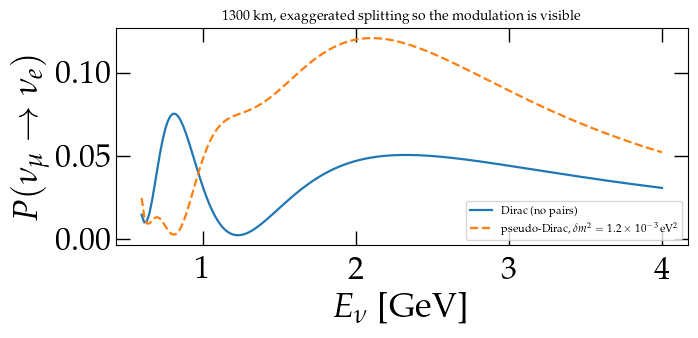

In [5]:
L_DUNE = 1300.0*gd.UNIT_KM
energies = np.linspace(0.6, 4.0, 200)*gd.UNIT_GEV
DM2_SHOWN = 1.2e-3                       # exaggerated, for visibility

with warnings.catch_warnings():
    # The splitting is not small against the standard ones, and the library says so.
    # That is the correct complaint; it is exaggerated on purpose here.
    warnings.simplefilter('ignore', hamiltonians.PseudoDiracSplittingWarning)
    H_pair = hamiltonians.hamiltonian_pseudo_dirac_vacuum_energy_independent(
        U, M2, {1: DM2_SHOWN, 2: DM2_SHOWN})
H_dirac = hamiltonians.hamiltonian_pseudo_dirac_vacuum_energy_independent(U, M2, {})

P_pair = np.array([np.asarray(oscprob.osc_prob(H_pair/e, 0.0, L_DUNE))[1, 0]
                   for e in energies])
P_dirac = np.array([np.asarray(oscprob.osc_prob(H_dirac/e, 0.0, L_DUNE))[1, 0]
                    for e in energies])

fig, ax = plt.subplots(figsize=(7.2, 3.6))
ax.plot(energies/gd.UNIT_GEV, P_dirac, lw=1.6, label='Dirac (no pairs)')
ax.plot(energies/gd.UNIT_GEV, P_pair, lw=1.6, ls='--',
        label=r'pseudo-Dirac, $\delta m^2 = 1.2\times10^{-3}$ eV$^2$')
ax.set_xlabel(r'$E_\nu$ [GeV]')
ax.set_ylabel(r'$P(\nu_\mu \to \nu_e)$')
ax.set_title('1300 km, exaggerated splitting so the modulation is visible', fontsize=10)
ax.legend(fontsize=8)
fig.tight_layout()

print('largest departure from the Dirac curve: %.4f' % float(np.max(np.abs(P_pair - P_dirac))))

## 4. At astrophysical distances the instantaneous probability is not an observable

At 100 Mpc and 100 TeV the standard phases are $\sim10^{14}$ radians. No experiment resolves
that, and neither does double precision. Sampling `osc_prob` at neighbouring energies -- close
enough that no detector could tell them apart -- returns values scattered across a large part
of the range.

This is the same lesson notebook 13 draws for the Sun, and it is why the rest of this notebook
works with the averaged probability.

In [6]:
L_100MPC = 100.0*MPC_IN_KM*gd.UNIT_KM
PAIRS_PHYS = {0: 2.6e-17, 1: 2.6e-17, 2: 2.6e-17}

H_astro = hamiltonians.hamiltonian_pseudo_dirac_vacuum_energy_independent(U, M2, PAIRS_PHYS)
nearby = 100.0*gd.UNIT_TEV*(1.0 + np.linspace(0.0, 1.0e-12, 40))
sampled = np.array([np.asarray(oscprob.osc_prob(H_astro/e, 0.0, L_100MPC))[0, 0]
                    for e in nearby])

print('40 energies spanning a relative range of 1e-12:')
print('  P_ee from %.4f to %.4f, spread %.4f' % (sampled.min(), sampled.max(), sampled.ptp()))
print()
print('The energies differ by one part in 1e12.  Nothing measures that, so the')
print('instantaneous probability is not the quantity an experiment reports.')

40 energies spanning a relative range of 1e-12:
  P_ee from 0.0389 to 0.2757, spread 0.2368

The energies differ by one part in 1e12.  Nothing measures that, so the
instantaneous probability is not the quantity an experiment reports.


## 5. The averaged regime, and the factor of two

Now the standard phases have averaged away and each pair is still coherent.
`coherence_blocks` sees exactly that: three blocks of two.

Two expressions are then in play. The **coherent-block** form sums *amplitudes* within a block
and squares once; the **naive** form sums probabilities, one term per eigenstate. Within a
block the pair splits its parent state's mixing evenly between two columns, so summing the
amplitudes rebuilds $|U_{\alpha j}|^2$ and the block form returns the ordinary Dirac answer.
Summing probabilities instead loses a factor of two.

In [7]:
W = hamiltonians.pseudo_dirac_mixing_matrix(U, PAIRS_PHYS)
masses = hamiltonians.pseudo_dirac_mass_squared(M2, PAIRS_PHYS)
eigenvalues = masses/(2.0*100.0*gd.UNIT_TEV)

blocks = avgprob.coherence_blocks(eigenvalues, L_100MPC)
print('coherence_blocks:', blocks)

def block_form(V, blocks, a, b):
    """The coherent-block average: sum amplitudes inside a block, then square."""
    return float(sum(abs(sum(np.conj(V[a, i])*V[b, i] for i in blk))**2
                     for blk in blocks).real)

def naive_sum(V, a, b):
    """One term per eigenstate: correct only once every pair has decohered."""
    return float(sum(abs(np.conj(V[a, i])*V[b, i])**2 for i in range(len(V))).real)

dirac = float(np.sum(np.abs(U[0, :])**4))
print()
print('  block form  <P_ee> = %.5f' % block_form(W, blocks, 0, 0))
print('  naive sum   <P_ee> = %.5f' % naive_sum(W, 0, 0))
print('  Dirac 3nu   <P_ee> = %.5f' % dirac)
print()
print('  block/naive = %.4f' % (block_form(W, blocks, 0, 0)/naive_sum(W, 0, 0)))

coherence_blocks: [[0, 1], [2, 3], [4, 5]]

  block form  <P_ee> = 0.54814
  naive sum   <P_ee> = 0.27407
  Dirac 3nu   <P_ee> = 0.54814

  block/naive = 2.0000


### A partially paired spectrum

The interface pairs individual mass states, which is more than a toggle: with partners on
states 0 and 2 only, the blocks come out as two-one-two and the unpaired state contributes its
ordinary single term.

In [8]:
PAIRS_PARTIAL = {0: 2.6e-17, 2: 2.6e-17}
W_partial = hamiltonians.pseudo_dirac_mixing_matrix(U, PAIRS_PARTIAL)
masses_partial = hamiltonians.pseudo_dirac_mass_squared(M2, PAIRS_PARTIAL)
blocks_partial = avgprob.coherence_blocks(
    masses_partial/(2.0*100.0*gd.UNIT_TEV), L_100MPC)

print('%d states, blocks %s' % (len(W_partial), blocks_partial))
print('  block form <P_ee> = %.5f' % block_form(W_partial, blocks_partial, 0, 0))
print('  naive sum  <P_ee> = %.5f' % naive_sum(W_partial, 0, 0))
print()
print('Between the fully paired case (a factor of two) and the Dirac case (no factor),')
print('as it must be: two of the three states carry a partner.')

5 states, blocks [[0, 1], [2], [3, 4]]
  block form <P_ee> = 0.54814
  naive sum  <P_ee> = 0.31963

Between the fully paired case (a factor of two) and the Dirac case (no factor),
as it must be: two of the three states carry a partner.


## 6. Sweeping the splitting through the three regimes

The library recognizes three regimes and refuses the middle one. Sweeping $\delta m^2$ upward
at fixed $L/E$ walks through all three: coherent pairs, then a band where neither limit
describes the physics, then full decoherence into six singletons.

`coherence_report` is what says which regime you are in, and the un-averaged probability is the
only valid route through the middle band.

In [9]:
print('%-12s %-32s %s' % ('dm2 [eV^2]', 'blocks', 'regime'))
print('-'*66)
for dm2 in (1.0e-19, 1.0e-18, 1.0e-17, 3.0e-17, 1.0e-16, 1.0e-15, 1.0e-13):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', hamiltonians.PseudoDiracSplittingWarning)
        masses_i = hamiltonians.pseudo_dirac_mass_squared(M2, {j: dm2 for j in range(3)})
    lam = masses_i/(2.0*100.0*gd.UNIT_TEV)
    blocks_i = avgprob.coherence_blocks(lam, L_100MPC)
    _, undecided = avgprob.coherence_report(lam, L_100MPC)
    sizes = sorted(len(b) for b in blocks_i)
    if sizes == [1]*6:
        regime = 'decohered: naive sum'
    elif undecided:
        # Grouped as pairs, but the pair phase has grown past the coherence
        # threshold: the cross term is neither kept nor dropped cleanly.
        regime = 'partly developed: NEITHER limit'
    else:
        regime = 'coherent pairs: block form'
    print('%-12.1e %-32s %s' % (dm2, str(blocks_i), regime))

dm2 [eV^2]   blocks                           regime
------------------------------------------------------------------
1.0e-19      [[0, 1], [2, 3], [4, 5]]         coherent pairs: block form
1.0e-18      [[0, 1], [2, 3], [4, 5]]         partly developed: NEITHER limit
1.0e-17      [[0, 1], [2, 3], [4, 5]]         partly developed: NEITHER limit
3.0e-17      [[0, 1], [2, 3], [4, 5]]         partly developed: NEITHER limit
1.0e-16      [[0], [1], [2], [3], [4], [5]]   decohered: naive sum
1.0e-15      [[0], [1], [2], [3], [4], [5]]   decohered: naive sum
1.0e-13      [[0], [1], [2], [3], [4], [5]]   decohered: naive sum


The middle band is not a numerical inconvenience: no averaged expression describes it.
Asking the library to average there raises `PhaseAveragingWarning` rather than returning a
number that looks fine.

In [10]:
lam_mid = hamiltonians.pseudo_dirac_mass_squared(
    M2, {j: 3.0e-17 for j in range(3)})/(2.0*100.0*gd.UNIT_TEV)
blocks_mid, undecided = avgprob.coherence_report(lam_mid, L_100MPC)

print('blocks:', blocks_mid)
print('pairs in neither limit (i, j, relative phase in radians):')
for i, j, relative_phase in undecided[:6]:
    print('   (%d, %d)   %.3f rad' % (i, j, relative_phase))
print()
print('That list is what makes the difference.  Empty, and one of the two averaged')
print('expressions applies.  Non-empty, as here, and neither does: the phases sit')
print('between %.2g and 2*pi, too large to keep the cross term and too small to' % 1.0e-2)
print('drop it.  The library raises PhaseAveragingWarning rather than choosing.')

blocks: [[0, 1], [2, 3], [4, 5]]
pairs in neither limit (i, j, relative phase in radians):
   (0, 1)   2.346 rad
   (2, 3)   2.346 rad
   (4, 5)   2.337 rad

That list is what makes the difference.  Empty, and one of the two averaged
expressions applies.  Non-empty, as here, and neither does: the phases sit
between 0.01 and 2*pi, too large to keep the cross term and too small to
drop it.  The library raises PhaseAveragingWarning rather than choosing.


## 7. On Earth, the effect is invisible

A useful negative result, and the guard against assuming the feature matters everywhere. At a
terrestrial baseline the physical pair phase is $\sim10^{-14}$ radians: the two members of each
pair have not begun to separate, so the spectrum is indistinguishable from Dirac.

In [11]:
H_earth_pair = hamiltonians.hamiltonian_pseudo_dirac_vacuum_energy_independent(
    U, M2, PAIRS_PHYS)
H_earth_dirac = hamiltonians.hamiltonian_pseudo_dirac_vacuum_energy_independent(U, M2, {})

energy = 1.0*gd.UNIT_GEV
P_pair_earth = np.asarray(oscprob.osc_prob(H_earth_pair/energy, 0.0, L_DUNE))[1, 0]
P_dirac_earth = np.asarray(oscprob.osc_prob(H_earth_dirac/energy, 0.0, L_DUNE))[1, 0]

print('1300 km, 1 GeV, dm2 = 2.6e-17 eV^2')
print('  pair phase              %.2e rad' % phase(2.6e-17, 1300.0, energy))
print('  P(numu->nue) Dirac       %.6f' % P_dirac_earth)
print('  P(numu->nue) pseudo-Dirac %.6f' % P_pair_earth)
print('  difference               %.2e' % abs(P_pair_earth - P_dirac_earth))
print()
print('Pseudo-Dirac splittings are an astrophysical-baseline effect.  Nothing')
print('terrestrial constrains them, which is the point of looking at neutrinos')
print('that have travelled megaparsecs.')

1300 km, 1 GeV, dm2 = 2.6e-17 eV^2
  pair phase              4.28e-14 rad
  P(numu->nue) Dirac       0.031266
  P(numu->nue) pseudo-Dirac 0.031266
  difference               1.94e-16

Pseudo-Dirac splittings are an astrophysical-baseline effect.  Nothing
terrestrial constrains them, which is the point of looking at neutrinos
that have travelled megaparsecs.


## What to take away

* Pairing is **per mass state**, so a partially paired spectrum is a first-class case.
* With nothing paired the Hamiltonian is the Dirac one to round-off, so the feature costs
  nothing when it is not used.
* In the coherent regime the **block form** returns the Dirac answer and the naive
  eigenstate sum is wrong by the number of states sharing a block.
* Between the two limits no averaged expression applies, and the library says so rather than
  returning a plausible number.
* The effect lives at astrophysical baselines. On Earth the pair phase is $10^{-14}$ radians.

---

**Previous:** [The paper's figures](28_magnus_paper_figures.ipynb)  
[API reference](https://mbustama.github.io/Magnus/functions.html) &middot; [Implementation details](https://mbustama.github.io/Magnus/implementation_details.html) &middot; [All notebooks](.)